# Relatório Final — Previsão de despesas em diárias e passagens (SCDP)

**Renê Estevam**, Rodrigo Costa, Liandro Silva  
Introdução a Machine Learning — [período / turma]

Este notebook segue o **template da Atividade 2** (modelagem supervisionada) e retoma o trabalho da **Atividade 1** (`rene_estevam_deckers.ipynb`): base **SCDP** (dados.gov.br), problema de **regressão** e variável alvo **Valor total** (R$).

---


## 1. Introdução

### Base de dados e enquadramento do estudo

* **Fonte dos dados:** conjunto *Viagens a Serviço do Governo Federal (SCDP)* em [dados.gov.br](https://dados.gov.br/dados/conjuntos-dados/viagens-a-servico-do-governo-federal-scdp). Arquivo CSV utilizado na Atividade 1 (ex.: `base_rene_estevam_deckers.csv`), com registros de diárias e passagens da administração pública federal.

* **Contextualização:** cada linha representa um trecho de viagem ou lançamento (órgão, unidade gestora, datas, motivo, valores de diárias/passagem, meio de transporte). Pode haver várias linhas por viagem. Os dados são relevantes para transparência, controle de custos e análise de padrões de gasto.

* **Objetivo da utilização:** treinar modelos de **aprendizado supervisionado** para estimar **valor da despesa** a partir de características da viagem/registro, como apoio à interpretação de custos e à priorização de auditorias (sem substituir regras orçamentárias ou normativas).

* **Problema de pesquisa:** *Qual o valor total da despesa a partir de características do registro de viagem?*  
  **Tipo:** aprendizado supervisionado — **regressão** (variável alvo contínua).

* **O que vai prever?** **Variável alvo (target):** **Valor total** (R$), custo total do registro na linha (diárias e passagens, conforme consta na base).

* **Dicionário de variáveis (Atividade 1):** ver `dicionario_rene_estevam_deckers.xlsx` — 23 variáveis documentadas.

> **Nota:** Na modelagem, evitar *data leakage*: não usar como *features* informações que, na prática, só estariam disponíveis depois de conhecido o valor total (ou que o reproduzam de forma trivial), salvo definição explícita do professor.

---


In [2]:
# Carregando os dados e preparando a base, seguindo os mesmos procedimentos usados na Atividade 1 (rene_estevam_deckers.ipynb)
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# avisos de versão futura do pandas poluem o output do relatório
warnings.filterwarnings("ignore", category=FutureWarning)

DATA_PATH = Path("base_rene_estevam_deckers.csv")
# None = lê o ficheiro todo; se a máquina engasgar, experimentar 200_000 ou 500_000 só para desenvolver
SAMPLE_NROWS = None

if not DATA_PATH.is_file():
    raise FileNotFoundError(
        f"CSV não encontrado: {DATA_PATH.resolve()}. Copie o mesmo ficheiro da Atividade 1 para esta pasta."
    )


def acha_col(df, *nomes):
    # tenta nome certo na exportação; às vezes o cabeçalho vem com tipo ou caractere estranho
    for n in nomes:
        if n in df.columns:
            return n
    for c in df.columns:
        # hífen "invisível" (U+00AD) já apareceu em nomes de coluna neste tipo de base
        if any(n in c for n in nomes) or c.replace("\u00ad", "").strip() in nomes:
            return c
    return None


def acha_por_palavras(df, palavras):
    # plano B: coluna cuja etiqueta contém todas as palavras (útil se mudarem o título)
    for c in df.columns:
        if all(p.lower() in c.lower() for p in palavras):
            return c
    return None


def to_num(s):
    # no CSV brasileiro o decimal vem com vírgula; o pandas read_csv nem sempre infere bem em colunas mistas
    if pd.isna(s):
        return np.nan
    return pd.to_numeric(str(s).strip().replace(",", "."), errors="coerce")


read_kw = dict(low_memory=False, encoding="utf-8")
if SAMPLE_NROWS is not None:
    read_kw["nrows"] = int(SAMPLE_NROWS)

df = pd.read_csv(DATA_PATH, **read_kw)
# há linhas repetidas no conjunto aberto — tiramos para não inflacionar médias
df = df.drop_duplicates()

# localizar nomes reais das colunas de valor (acentos podem variar entre downloads)
col_valor_total = acha_col(df, "Valor total") or acha_por_palavras(df, ["Valor", "total"])
col_valor_diarias = acha_col(df, "Valor diárias", "Valor diarias") or acha_por_palavras(
    df, ["Valor", "diarias"]
)
col_valor_passagem = acha_col(df, "Valor passagem") or acha_por_palavras(df, ["Valor", "passagem"])
col_num_diarias = (
    acha_col(df, "Número diárias", "Numero diarias")
    or acha_por_palavras(df, ["Número", "diárias"])
    or acha_por_palavras(df, ["Numero", "diarias"])
)

for col in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias]:
    if col is not None and col in df.columns:
        df[col] = df[col].apply(to_num)

# cópia numérica estável para gráficos e para o y do modelo (nome fixo)
df["valor_total_num"] = df[col_valor_total]
COLS_NUM = [c for c in [col_valor_total, col_valor_diarias, col_valor_passagem, col_num_diarias] if c]

print("Shape:", df.shape)
print("Colunas numéricas convertidas:", COLS_NUM)
df.head()


Shape: (2215246, 24)
Colunas numéricas convertidas: ['Valor total', 'Valor diárias', 'Valor passagem', 'Número diárias']


,Código órgão superior,Nome órgão superior,Código órgão,Nome órgão,Código unidade gestora,Nome unidade gestora,Nome servidor,Cargo,Data início viagem,Data término viagem,...,Município origem,UF origem,Município destino,UF destino,Número diárias,Valor diárias,Meio de transporte,Categoria passagem,Valor passagem,valor_total_num
0,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,2.0,642.56,Veículo Oficial,NaN,0.0,803.20
1,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-03-20,2017-03-24 00:00:00,...,NaN,NaN,NaN,NaN,0.5,160.64,Veículo Oficial,NaN,0.0,803.20
2,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,1.0,386.36,Veículo Oficial,NaN,0.0,579.54
3,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-06-30,2017-07-02 00:00:00,...,NaN,NaN,NaN,NaN,0.5,193.18,Veículo Oficial,NaN,0.0,579.54
4,20000,PRESIDENCIA DA REPUBLICA,20000,PRESIDENCIA DA REPUBLICA,110037.0,SECT DE SEG PRESIDENCIAL/GSIPR,ACACIO PEREIRA CAMPOS,NaN,2017-08-14,2017-08-15 00:00:00,...,NaN,NaN,NaN,NaN,0.5,182.00,Veículo Oficial,NaN,0.0,364.00


## 2. Análise Descritiva Preliminar

No relatório preliminar (`rene_estevam_deckers.ipynb`) trabalhou-se o mesmo conjunto SCDP: após **remoção de duplicatas** e **conversão numérica** dos campos de valores e de *Número diárias*, obteve-se uma base com mais de **dois milhões** de linhas. O **Valor total** (alvo) mostrou **forte assimetria à direita** — média bem acima da mediana e cauda longa —, o que antecipa sensibilidade a *outliers* e, na modelagem, a eventual necessidade de transformação ou de algoritmos robustos a extremos.

O **Valor passagem** mistura **muitos zeros** (registros sem compra de passagem naquele lançamento), valores positivos numa cauda e **pouquíssimos negativos** associados a ajustes administrativos. **Município/UF** de origem e destino e **Categoria passagem** apresentam **taxas altas de ausência**; **Cargo** e textos como **Motivo** e **Meio de transporte** exigem política clara de imputação, agrupamento de categorias raras ou *encoding* na fase de pré-processamento.

Na associação linear com o alvo, destacaram-se a **duração da viagem em dias** (intervalo entre datas de término e início), o **Número diárias** e o **Valor diárias**. O estudo preliminar assinalou ainda **correlação elevada entre Número diárias e Valor diárias**, com implicações de **multicolinearidade** em modelos lineares — situação em que convém não usar ambas sem critério (por exemplo regularização ou modelos baseados em árvores). Os gráficos da primeira entrega mostraram **heterogeneidade da mediana do Valor total por Motivo** e variação da soma mensal agregada por **mês de início da viagem**.

O detalhe das tabelas, percentuais de *missing*, matrizes de correlação e figuras encontra-se no **notebook da Atividade 1**. A **célula de código anterior** apenas **reimporta** o CSV e prepara `df`, `COLS_NUM`, os identificadores `col_valor_*`, `col_num_diarias` e `valor_total_num` para as etapas seguintes. A **construção e seleção de variáveis preditoras**, o tratamento de ausentes e categorias e as decisões face à **multicolinearidade** integram a **secção 4** (pré-processamento), juntamente com limpeza, codificação e escala.


## 3. Divisão dos dados

### Estratégia

- **Separação treino/teste (hold-out):** usamos **80% para treino** e **20% para teste** (`test_size=0.2`). A ideia é treinar e ajustar tudo no treino e deixar o teste guardado para uma **checagem final** de generalização.
- **Reprodutibilidade:** fixamos `random_state=42`, então o sorteio das linhas fica **igual** toda vez que o notebook roda (importante para o relatório).
- **Por que estratificar num problema de regressão:** o **Valor total** tem muitos valores baixos e poucos valores muito altos (cauda longa). Se a divisão for totalmente aleatória, pode acontecer (mesmo com muito dado) de um lado cair “mais caro” que o outro. Para reduzir isso, fazemos uma **estratificação por faixas do alvo**: transformamos `y` em **decis** com `pd.qcut` e passamos essas faixas no `stratify`.

  - **O que é `pd.qcut` (qcut):** é uma função do pandas que **“corta”** uma variável numérica contínua em **faixas por quantis**.
  - **O que são decis (decis/deciles):** quando a gente pede `q=10`, o `qcut` cria **10 faixas** chamadas de **decis**. Em termos simples, cada decil tem **aproximadamente 10% das linhas** (na medida do possível). Exemplo intuitivo: o **1º decil** pega os ~10% menores valores de `y` e o **10º decil** pega os ~10% maiores.
  - **Por que isso ajuda aqui:** como o `train_test_split` não consegue estratificar direto em valores contínuos, a gente cria essas faixas (bins) e estratifica nelas. Assim, treino e teste tendem a manter uma **proporção parecida** de valores baixos/médios/altos.
  - **Detalhe importante:** `pd.qcut(..., duplicates="drop")` evita erro quando existem muitos valores repetidos e alguns cortes “empatam” (o pandas então reduz o número real de faixas).
- **Plano B automático:** se o `qcut` não conseguir formar faixas estáveis (por empates/quantis), o código volta para um *split* aleatório simples e imprime um aviso.
- **Linhas sem alvo:** registros com `valor_total_num` ausente são removidos antes do *split* (sem `y`, não tem como supervisionar o modelo).

### Justificativa

- **Tamanho do teste:** como a base é grande, 20% ainda gera um teste com muitas observações. Isso deixa RMSE/MAE/R² no teste **menos sensíveis ao acaso**.
- **Evitar vazamento (data leakage):** o conjunto de teste não participa do ajuste do pré-processamento (medianas, modas, escalonamento, categorias do one-hot) nem do ajuste do modelo. Isso deixa a avaliação final mais honesta.
- **Alternativa que faria sentido (mas não foi usada aqui):** um *split* temporal (treinar no passado e testar no período mais recente) simula melhor “previsão do futuro”, mas exige discutir com cuidado quais datas representam o momento real do gasto/registro. Para seguir o template e manter simplicidade, ficamos com o hold-out aleatório estratificado.

**Features para `X`:** entram todas as colunas do `df` **menos** o alvo duplicado (`valor_total_num`) e, se existir, a coluna original **Valor total**.

---


In [3]:
from sklearn.model_selection import train_test_split
import pandas as pd

# coluna do alvo (numérica); mantém o mesmo nome usado desde o carregamento do CSV
TARGET_COL = "valor_total_num"

# vetor y
y = df[TARGET_COL]
# tira do X o alvo e, se houver, a coluna "Valor total" em texto/duplicada
drop_x = {TARGET_COL}
if col_valor_total and col_valor_total in df.columns:
    drop_x.add(col_valor_total)

# só entram preditoras aqui
X = df.drop(columns=[c for c in drop_x if c in df.columns], errors="ignore")

# linha sem despesa não entra no modelo supervisionado
m = y.notna()
X, y = X.loc[m].copy(), y.loc[m]

# fixos para o resultado bater sempre igual no relatório
TEST_SIZE = 0.2
RANDOM_STATE = 42
N_BINS = 10

try:
    # faixas do valor (tipo decis) para o stratify não sortear só barato ou só caro num dos lados
    y_bins = pd.qcut(y, q=N_BINS, duplicates="drop")
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=y_bins,
    )
    used_strat = True
except ValueError as exc:
    # se os bins falharem (poucas linhas num quantil, etc.), volta ao split aleatório comum
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
    )
    used_strat = False
    print("Aviso: estratificação por decis indisponível — split puramente aleatório.")
    print("  ", exc)

print("Shapes — X_train:", X_train.shape, "| X_test:", X_test.shape)
print("Média y_train:", float(y_train.mean()), "| Média y_test:", float(y_test.mean()))
print("Estratificação por faixas do alvo (qcut):", used_strat)


Shapes — X_train: (1772187, 22) | X_test: (443047, 22)
Média y_train: 1497.2632601807825 | Média y_test: 1493.8066979124112
Estratificação por faixas do alvo (qcut): True


## 4. Pré-processamento dos Dados

O pré-processamento **combina** **construção e seleção de variáveis preditoras** (engenharia de variáveis), **limpeza e ausentes**, **codificação de categóricas** e **padronização** quando o algoritmo exigir. O ideal é encapsular tudo em **Pipeline** (`ColumnTransformer` + estimador), com ajuste **só no treino**, para evitar *data leakage* para o conjunto de teste.

### 4.1 Construção e seleção de variáveis preditoras

- **Variável derivada das datas (função `engenharia_preditoras`):** criamos **`duracao_dias`** a partir da diferença entre a data de término e a de início da viagem (valores negativos são cortados a zero). Na Atividade 1 esta medida associou-se ao **Valor total**. Depois do cálculo, **eliminamos** as colunas de **datas em bruto** e de **início/fim de trecho** em texto, para não repetir a mesma informação nem forçar *dtype* misto no `ColumnTransformer`.

- **Multicolinearidade e o que o código resolve:** no relatório preliminar, **Número diárias** e **Valor diárias** apresentaram **correlação elevada**. Em regressão linear isso pode **inflar a variância** dos coeficientes e tornar os sinais instáveis. **Aqui a prioridade não é “ficar só com uma das duas” por um critério puramente estatístico:** removemos **`Valor diárias`** das preditoras porque, em termos de *leakage*, é **parcela monetária** que entra no **Valor total** na mesma linha (ver ponto seguinte). Com isso, **o par problemático entre quantidade e valor monetário das diárias deixa de existir** no modelo. Mantemos **`Número diárias`** como variável de quantidade. **Outras** associações lineares entre numéricas (por exemplo entre `duracao_dias` e `Número diárias`) podem continuar; na secção 5, **Ridge/Lasso** ajudam a regularizar coeficientes em modelos lineares, enquanto **árvores e *ensembles*** tratam interacções e não linearidades de forma diferente.

- **Alta cardinalidade:** campos como órgão ou município têm muitas categorias. No código (secção 4.3) usamos `OneHotEncoder` com **`max_categories=25`** por variável e **`handle_unknown='ignore'`**, em vez de gerar dezenas de milhares de colunas *dummy* sem limite.

- ***Leakage* — o que está excluído e porquê (coerente com o código):** (1) Na secção 3, `X` **não inclui** `valor_total_num` nem a coluna textual do **Valor total**. (2) Em `engenharia_preditoras` **retiramos** **`Valor diárias`** e **`Valor passagem`**: são **parcelas** que somam ao custo total registado na linha; usá-las como *features* aproxima-se de **reconstruir** o alvo. (3) **Removemos `Nome servidor`**, identificador individual, pouco relevante para um modelo de despesa agregada e sensível em termos de privacidade. (4) O **pré-processamento** (`fit` do `ColumnTransformer`) usa **apenas o treino**; medianas, modas e parâmetros do escalonamento **não** são calculados com o teste (detalhe nas 4.2–4.3).

### 4.2 Limpeza e valores ausentes

- **Duplicatas:** na célula de carregamento aplicou-se `drop_duplicates()` ao CSV bruto, antes de qualquer modelagem.
- **Alvo:** antes do *split*, removem-se linhas em que `valor_total_num` é ausente — sem *y* não há aprendizagem supervisionada.
- **Preditoras (depois da engenharia da secção 4.1):** usamos `SimpleImputer` com `fit` **apenas no treino**: **mediana** nas variáveis numéricas (menos sensível a *outliers* e à cauda longa observada na Atividade 1) e **valor mais frequente** nas categóricas. No `transform`, treino e teste reutilizam essas estatísticas — nada é recalculado com o teste.
- **Sem categoria explícita "não informado":** em vez de acrescentar uma etiqueta textual para *missing*, o imputador preenche os vazios antes do *one-hot*, o que controla o número de *dummies* e combina com `handle_unknown='ignore'` quando aparecem categorias novas no teste.
- **Colunas sem informação no treino:** preditoras numéricas ou categóricas em que **não há nenhum valor não nulo** no treino são excluídas desse ramo (código: só entram colunas com pelo menos um valor observado no treino).

### 4.3 Codificação, padronização e Pipeline

- **Separação por tipo:** após `engenharia_preditoras`, classificamos colunas em **numéricas** e **categóricas** (`object`, *string*, *category*) para dois ramos do `ColumnTransformer`; o resto é descartado (`remainder='drop'`).
- **Numéricas:** *pipeline* imputação (mediana) → `StandardScaler` (média 0, variância 1). A padronização interessa sobretudo a **modelos lineares e regularizados** (Ridge/Lasso) da secção 5; modelos por árvores são menos dependentes da escala, mas um único pré-processamento permite **comparar algoritmos** na mesma matriz de *features*.
- **Categóricas:** imputação (moda) → `OneHotEncoder` com **até 25 categorias** por variável (`max_categories`), `handle_unknown='ignore'` e saída em **matriz esparsa** — necessário com milhões de linhas e muitas *dummies*.
- **Objecto `preprocessor`:** será **encadeado ao estimador** com `sklearn.pipeline.Pipeline` na secção 5 (`fit` só em `X_train`, avaliação honesta no teste da secção 3). As matrizes `X_train_prep` e `X_test_prep` na célula abaixo servem para inspecção de dimensão; na modelagem final o recomendável é o `Pipeline` completo sobre `X_train_fe` / `X_test_fe`.

---

### Decisões adotadas neste relatório (implementação abaixo)

- **Alvo:** continua a ser `valor_total_num` (definido antes do *split*). O pré-processamento aplica-se só a **preditoras** em `X_train` / `X_test`.
- **Engenharia:** criamos **`duracao_dias`** a partir das datas de início e fim da viagem; removemos as colunas de **data em bruto** depois de calcular a duração (evita misturar *object/datetime* com o resto do *Pipeline*).
- **Leakage / soma trivial:** retiramos **`Valor diárias`** e **`Valor passagem`** do conjunto de preditoras — são parcelas que entram no **Valor total**; mantê-las como *features* aproxima-se de reproduzir o total em vez de aprender padrões da viagem. Mantemos **`Número diárias`** como quantidade.
- **Identificação de pessoas:** removemos **`Nome servidor`** (identificador directo; não é necessário ao modelo agregado).
- **Ausentes:** medianas nas numéricas; valor mais frequente nas categóricas antes do *one-hot*.
- **Cardinalidade:** `OneHotEncoder` com `max_categories` por coluna e `handle_unknown='ignore'`; saída **esparsa** para caber na RAM com milhões de linhas.
- **Encadeamento:** `fit` **só** em `X_train_fe`; `transform` em treino e teste — sem usar estatísticas do teste no *fit*.


In [4]:
# --- Seção 4: pré-processamento (fit no treino; transform no treino e no teste) ---
# Antes precisa ter rodado a célula do split (X_train, X_test) e a do CSV (col_valor_diarias, col_valor_passagem, etc.).

import numpy as np  # sem isso o select_dtypes(..., np.number) não acha o tipo
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer


def acha_col_x(df, *nomes):
    # Igual na leitura do arquivo: nome da coluna no portal muda (acento, typo, esse hífen invisível U+00AD).
    for n in nomes:
        if n in df.columns:
            return n
    for c in df.columns:
        if any(n in c for n in nomes) or c.replace("\u00ad", "").strip() in nomes:
            return c
    return None


def _make_one_hot():
    # One-hot denso nessa base fica pesado em memória; por isso usamos saída esparsa. (O nome do parâmetro muda entre versões do sklearn.)
    # ignore no handle_unknown: categoria nova no teste não derruba o transform.
    # max_categories: amarra quantas dummies por coluna (senão vira coluna demais).
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            max_categories=25,
            sparse_output=True,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            max_categories=25,
            sparse=True,
        )


def engenharia_preditoras(X_df):
    # _fe = depois de criar variável nova e tirar o que não vai pro modelo
    out = X_df.copy()

    col_ini = acha_col_x(out, "Data início viagem", "Data inicio viagem")
    col_fim = acha_col_x(out, "Data término viagem", "Data termino viagem")
    if col_ini and col_fim and col_ini in out.columns and col_fim in out.columns:
        t0 = pd.to_datetime(out[col_ini], errors="coerce")
        t1 = pd.to_datetime(out[col_fim], errors="coerce")
        # coerce: lixo vira NaN; NaN de data a gente trata no imputer depois
        out["duracao_dias"] = (t1 - t0).dt.total_seconds() / (24 * 3600)
        out["duracao_dias"] = out["duracao_dias"].clip(lower=0)

    # Já temos duracao_dias; data crua e trecho em texto só atrapalham tipo de coluna no transformer
    for c in [
        col_ini,
        col_fim,
        acha_col_x(out, "Início trecho", "Inicio trecho"),
        acha_col_x(out, "Término trecho", "Termino trecho"),
    ]:
        if c and c in out.columns:
            out = out.drop(columns=[c])

    # col_valor_* vem da célula de carga — é pedaço do total; manter é vazar o alvo
    for c in [col_valor_diarias, col_valor_passagem]:
        if c and c in out.columns:
            out = out.drop(columns=[c])

    if "Nome servidor" in out.columns:
        out = out.drop(columns=["Nome servidor"])

    return out


X_train_fe = engenharia_preditoras(X_train)
X_test_fe = engenharia_preditoras(X_test)

# Lista de colunas num/cat olhando só o treino — é dele que vêm mediana, moda e “dicionário” do one-hot
num_cols = X_train_fe.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_fe.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

# Coluna só missing no treino: imputer não tem o que aprender; melhor tirar
num_cols = [c for c in num_cols if X_train_fe[c].notna().any()]
cat_cols = [c for c in cat_cols if X_train_fe[c].notna().any()]

numeric_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

transformers = [("num", numeric_pipe, num_cols)]
if cat_cols:
    categorical_pipe = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", _make_one_hot()),
        ]
    )
    transformers.append(("cat", categorical_pipe, cat_cols))

try:
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False,
    )
except TypeError:
    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

# Fit só no treino — se misturar teste aqui, vaza
preprocessor.fit(X_train_fe)
X_train_prep = preprocessor.transform(X_train_fe)
X_test_prep = preprocessor.transform(X_test_fe)

print("Preditoras numéricas:", len(num_cols), "| categóricas:", len(cat_cols))
print("Matriz treino após transformação:", X_train_prep.shape, "| tipo:", type(X_train_prep).__name__)
print("Matriz teste:", X_test_prep.shape)




Preditoras numéricas: 5 | categóricas: 11
Matriz treino após transformação: (1772187, 241) | tipo: csr_matrix
Matriz teste: (443047, 241)


## 5. Construção e escolha do modelo

- **Ideia:** cada candidato é um `Pipeline` com o **mesmo** `ColumnTransformer` da seção 4 (`clone(preprocessor)` para não reaproveitar um objeto já treinado) + um regressor. O `fit` do pipeline refaz o pré-processamento e o modelo junto, só com **treino**.
- **Métricas na validação cruzada:** RMSE, MAE e R² médios (e desvio entre *folds*) no **treino**, via `cross_validate`. O conjunto de **teste** da seção 3 **não entra** aqui — só na avaliação final (seção 7).
- **Candidatos:** **Ridge** (linear regularizada; aceita a saída esparsa do one-hot). **HistGradientBoostingRegressor** e **Random Forest** — nas versões atuais do scikit-learn costumam exigir **matriz densa**; por isso, depois do `ColumnTransformer`, há um passo que chama `.toarray()`. Isso pesa na **RAM**; por isso existem `AMOSTRA_CV` e `AMOSTRA_RF`. A RF usa subamostra menor por ser mais pesada.
- **Desempenho vs. tempo:** na base completa, a validação cruzada pode levar bastante tempo. A constante `AMOSTRA_CV` limita o número de linhas usadas na comparação; se a máquina suportar, `None` usa 100% do treino.

---


In [5]:
# --- Seção 5: candidatos a modelo (validação cruzada só no treino) ---
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_validate

# None = usa todas as linhas do treino na CV (bem pesado)
AMOSTRA_CV = 350_000
# Random Forest precisa de matriz densa; limita linhas pra não estourar RAM
AMOSTRA_RF = 120_000
CV_FOLDS = 3


def _subamostra(X, y, n, seed=42):
    # CV com ~1,7M de linhas pode ser bem demorada. Aqui a gente usa uma amostra aleatória do TREINO para viabilizar a comparação.
    # - Se n=None: usa todas as linhas
    # - Se n for menor: usa n linhas
    # A amostra mantém o MESMO índice em X e y, para não desalinhar preditoras e alvo.
    if n is None or len(X) <= n:
        return X, y
    Xs = X.sample(n=n, random_state=seed)
    return Xs, y.loc[Xs.index]


def _esparso_para_denso(X):
    # Alguns modelos (como RandomForest e, dependendo da versão, HistGradientBoosting) não aceitam matriz esparsa.
    # Como o one-hot gera uma matriz esparsa, às vezes precisamos converter para denso com .toarray().
    # Observação: isso aumenta bastante o uso de memória; por isso a RF usa uma amostra menor (AMOSTRA_RF).
    return X.toarray() if hasattr(X, "toarray") else X


def _cv_metrics(nome, pipeline, X, y, cv=CV_FOLDS):
    # Roda validação cruzada e devolve um resumão (média e desvio) das métricas.
    # Eu deixei tudo aqui numa função pra não repetir o mesmo bloco pra cada modelo.
    # Métricas negadas no sklearn: pra RMSE a gente usa MSE e tira a raiz depois.
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "mse": "neg_mean_squared_error",
            "mae": "neg_mean_absolute_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )
    # O sklearn devolve MSE/MAE como "neg_*" (convenção dele: maior é melhor). Aqui a gente volta pro sinal normal.
    rmse_folds = np.sqrt(-scores["test_mse"])  # RMSE por fold = raiz do MSE (mesma unidade do alvo, R$)
    mae_folds = -scores["test_mae"]  # MAE por fold = erro absoluto médio (também em R$)
    r2_folds = scores["test_r2"]  # R² por fold = variância explicada
    return {
        "modelo": nome,
        "RMSE_cv_mean": rmse_folds.mean(),  # média do RMSE nos folds (quanto menor, melhor)
        "RMSE_cv_std": rmse_folds.std(),  # desvio-padrão do RMSE entre folds (se alto, o resultado varia bastante)
        "MAE_cv_mean": mae_folds.mean(),  # média do MAE nos folds
        "MAE_cv_std": mae_folds.std(),  # desvio-padrão do MAE entre folds
        "R2_cv_mean": r2_folds.mean(),  # média do R² nos folds
        "R2_cv_std": r2_folds.std(),  # desvio-padrão do R² entre folds
    }


# Se AMOSTRA_CV estiver definido, a gente pega uma fatia aleatória do treino só pra rodar a CV mais rápido.
# Importante: continua sendo *só treino* (não encosta no X_test) e preserva o pareamento X/y pelo índice.
X_cv, y_cv = _subamostra(X_train_fe, y_train, AMOSTRA_CV)

linhas = []

pipe_ridge = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("reg", Ridge(alpha=1.0)),
    ]
)
linhas.append(_cv_metrics("Ridge", pipe_ridge, X_cv, y_cv))

# Nesta versão do sklearn o HistGradientBoosting só aceita X denso (erro se vier esparsa do one-hot)
pipe_hgb = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("para_denso", FunctionTransformer(_esparso_para_denso, validate=False)),
        (
            "reg",
            HistGradientBoostingRegressor(
                max_iter=150,
                max_depth=12,
                learning_rate=0.08,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.1,
                n_iter_no_change=10,
            ),
        ),
    ]
)
linhas.append(_cv_metrics("HistGradientBoosting", pipe_hgb, X_cv, y_cv))

X_rf, y_rf = _subamostra(X_train_fe, y_train, AMOSTRA_RF)
pipe_rf = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("para_denso", FunctionTransformer(_esparso_para_denso, validate=False)),
        (
            "reg",
            RandomForestRegressor(
                n_estimators=80,
                max_depth=18,
                max_samples=0.5,
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)
linhas.append(_cv_metrics("RandomForest", pipe_rf, X_rf, y_rf))

resultados_cv = pd.DataFrame(linhas).sort_values("RMSE_cv_mean")
display(resultados_cv)

MODEL_NAME_BEST_CV = resultados_cv.iloc[0]["modelo"]
print("Menor RMSE médio na CV (entre os três):", MODEL_NAME_BEST_CV)


,modelo,RMSE_cv_mean,RMSE_cv_std,MAE_cv_mean,MAE_cv_std,R2_cv_mean,R2_cv_std
2,RandomForest,1073.966200,88.868439,351.413306,2.630829,0.935892,0.007961
1,HistGradientBoosting,1193.762429,151.984001,384.817144,15.847387,0.918794,0.019099
0,Ridge,1272.284574,58.094255,469.406861,2.044438,0.909200,0.004320


Menor RMSE médio na CV (entre os três): RandomForest


### Interpretação dos resultados (validação cruzada no treino)

Pela tabela acima (valores exatos dependem da sua execução), dá para ler o seguinte:

- **Ranking por erro:** o modelo com **menor RMSE médio na CV** foi o indicado na última linha impressa — na nossa execução, a **RandomForest** ficou à frente do **HistGradientBoosting** e do **Ridge**. Isso sugere que, com as *features* e o pré-processamento atuais, relações **não lineares** e **interações** (bem captadas por *ensembles* de árvores) ajudam mais do que um modelo **linear** com penalização L2 (Ridge) e `alpha` ainda genérico.

- **Ridge em último:** não significa que regressão linear seja “ruim” em geral — aqui o alvo tem **cauda longa** e muitas entradas após o *one-hot*; sem afinar `alpha` (secção 6) e sem *features* mais elaboradas, o linear tende a ficar atrás dos *ensembles* neste tipo de base.

- **RMSE maior que o MAE** nos três casos: o RMSE penaliza mais erros grandes. Quando RMSE ≫ MAE, costuma haver **predições bem piores em alguns pontos** (valores extremos de despesa), coerente com *outliers* e assimetria do **Valor total** vistas na Atividade 1.

- **R² na CV em torno de 0,91–0,94:** no treino (por *folds*), o modelo explica **boa parte da variância** do alvo. Ainda assim, isso é **validação cruzada**, não o teste final: o desempenho **real** de generalização só se confirma na **seção 7**, no conjunto de teste reservado na seção 3 — e a secção 6 pode mudar hiperparâmetros e o “vencedor” da CV.

- **Comparabilidade:** Ridge e HGB usam a mesma subamostra `AMOSTRA_CV`; a **Random Forest** usa `AMOSTRA_RF` (menor). Isso muda um pouco a “justiça” da comparação numérica, mas não invalida a leitura geral: *ensembles* de árvore vs. linear.

#### O que significa `RMSE_cv_std` e `R2_cv_std` (e por que o HistGradientBoosting “oscila” mais)

- **Média (`*_mean`)** resume o desempenho típico na validação cruzada. **Desvio-padrão (`*_std`)** mede **quanto o resultado muda de um *fold* para outro**: quanto **maior o std**, mais o modelo “depende” de qual pedaço dos dados ficou como validação naquela rodada.
- No seu resultado, o **HistGradientBoosting** costuma aparecer com **std maior** no RMSE e no R² do que a **Random Forest** e o **Ridge**. Dá para tirar conclusões **moderadas** (porque só temos **3 folds** — o std já é uma estimativa “grosseira”):
  - **Ridge com std baixo:** o modelo linear + regularização tende a ser **mais estável** entre *folds* (menos variação), mesmo quando o erro médio é pior.
  - **Random Forest no meio-termo:** *bagging* costuma suavizar variância em relação a um único ajuste de árvore.
  - **Boosting com std maior:** o **gradient boosting** é **sequencial** (cada árvore corrige erros das anteriores) e costuma ser **mais sensível** ao subconjunto de treino/validação de cada *fold*. Além disso, no nosso código o HGB usa **early stopping** (parte interna de validação) — isso pode **amplificar** diferenças entre *folds* quando a amostra é grande e heterogênea.
- **Interpretação prática:** o HGB **não está “errado”** só porque oscila mais entre *folds*. Ele pode até ter potencial (especialmente depois de afinar hiperparâmetros na seção 6), mas o padrão sugere que, **nesta configuração**, ele é **menos estável** que a RF. A decisão final ainda deve considerar **teste** (seção 7) e, se possível, repetir com mais *folds* ou `random_state` para ver se o std baixa.

- **Próximo passo:** na **seção 6**, refinar hiperparâmetros (em geral **RF** e **HGB**); na **seção 7**, avaliar no **teste** guardado.


## 6. Otimização de hiperparâmetros

Na seção 5 a gente comparou 3 modelos com um conjunto “ok” de parâmetros só pra ter uma referência. Agora a ideia é **refinar** os modelos mais promissores **sem encostar no teste**.

### Estratégia (para manter viável)

- **Busca:** `RandomizedSearchCV` (mais rápido que `GridSearchCV` quando o espaço é grande).
- **Somente treino:** a busca roda em `X_train_fe`/`y_train` (ou numa subamostra do treino), com `cv` interno. O conjunto `X_test` fica guardado pra seção 7.
- **Métrica principal:** a busca usa **MSE negativo** (padrão do sklearn) e a gente converte pra **RMSE** só na hora de imprimir.
- **Custo computacional:** RF e (na sua versão) HGB precisam de **matriz densa** depois do one-hot; por isso usamos subamostras (`AMOSTRA_SEARCH`) pra não estourar RAM/tempo.

O resultado esperado aqui é: **melhores parâmetros** e um **pipeline final** candidato pra ser avaliado no teste na seção 7.

---


In [ ]:
# --- Seção 6: otimização de hiperparâmetros (RandomizedSearchCV) ---
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV


def _esparso_para_denso(X):
    # Mesma ideia da seção 5: alguns estimadores não aceitam matriz esparsa.
    return X.toarray() if hasattr(X, "toarray") else X


def _subamostra(X, y, n, seed=42):
    # Subamostra do treino pra busca não demorar uma eternidade
    if n is None or len(X) <= n:
        return X, y
    Xs = X.sample(n=n, random_state=seed)
    return Xs, y.loc[Xs.index]


# Se a máquina aguentar, dá pra colocar None (mas costuma ficar pesado)
AMOSTRA_SEARCH = 200_000
CV_SEARCH = 3
N_ITER = 18
SEED = 42

X_s, y_s = _subamostra(X_train_fe, y_train, AMOSTRA_SEARCH, seed=SEED)

# ------------------------
# 1) Random Forest (denso)
# ------------------------
pipe_rf = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("para_denso", FunctionTransformer(_esparso_para_denso, validate=False)),
        ("reg", RandomForestRegressor(random_state=SEED, n_jobs=-1)),
    ]
)

param_rf = {
    "reg__n_estimators": [120, 200, 300],
    "reg__max_depth": [12, 16, 20, None],
    "reg__min_samples_split": [2, 5, 10],
    "reg__min_samples_leaf": [1, 2, 4],
    "reg__max_features": ["sqrt", 0.5, 0.8],
    "reg__max_samples": [0.3, 0.5, 0.8, None],
}

search_rf = RandomizedSearchCV(
    pipe_rf,
    param_distributions=param_rf,
    n_iter=N_ITER,
    cv=CV_SEARCH,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

search_rf.fit(X_s, y_s)

best_rmse_rf = np.sqrt(-search_rf.best_score_)
print("\nMelhor RF (CV) — RMSE:", round(best_rmse_rf, 2))
print("Melhores params RF:")
print(search_rf.best_params_)

# -----------------------------------
# 2) HistGradientBoosting (denso aqui)
# --------------------------------------
pipe_hgb = Pipeline(
    [
        ("prep", clone(preprocessor)),
        ("para_denso", FunctionTransformer(_esparso_para_denso, validate=False)),
        ("reg", HistGradientBoostingRegressor(random_state=SEED, early_stopping=True)),
    ]
)

# --- Porque o param_hgb está assim (resumido) ---
# Não há fórmula mágica: são faixas "no ouvido" + o que já tínhamos visto na secção 5 (HGB oscilava
# mais entre folds). learning_rate baixo (0,03–0,05) pede max_iter maior; rate mais alto (0,08–0,12)
# costuma parar mais cedo pelo early_stopping, por isso não faz sentido ir buscar max_iter gigantes.
# max_depth 6 a 14 (e None): limitar profundidade ajuda quando há muito ruído e categorias raras;
# None fica lá para o caso de o modelo preferir deixar crescer se o resto da regularização segurar.
# min_samples_leaf alto (20–80): com one-hot enorme, folhas com 1 ou 2 linhas aparecem à bruta —
# isto força um mínimo de massa por folha e costuma baixar variança entre folds.
# l2 de 0 a 5: 0 para não castigar à toa; subir quando queremos travar coeficientes/árvores mais "nervosas".
param_hgb = {
    "reg__max_iter": [120, 200, 350],
    "reg__learning_rate": [0.03, 0.05, 0.08, 0.12],
    "reg__max_depth": [6, 10, 14, None],
    "reg__min_samples_leaf": [20, 40, 80],
    "reg__l2_regularization": [0.0, 0.1, 1.0, 5.0],
}

search_hgb = RandomizedSearchCV(
    pipe_hgb,
    param_distributions=param_hgb,
    n_iter=min(N_ITER, 16),
    cv=CV_SEARCH,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

search_hgb.fit(X_s, y_s)

best_rmse_hgb = np.sqrt(-search_hgb.best_score_)
print("\nMelhor HGB (CV) — RMSE:", round(best_rmse_hgb, 2))
print("Melhores params HGB:")
print(search_hgb.best_params_)

# ------------------------------
# 3) Ridge (rápido, opcional)
# ------------------------
pipe_ridge = Pipeline([("prep", clone(preprocessor)), ("reg", Ridge())])
param_ridge = {"reg__alpha": [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]}

search_ridge = RandomizedSearchCV(
    pipe_ridge,
    param_distributions=param_ridge,
    n_iter=min(10, len(param_ridge["reg__alpha"])),
    cv=CV_SEARCH,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=SEED, 
)
search_ridge.fit(X_s, y_s)

best_rmse_ridge = np.sqrt(-search_ridge.best_score_)
print(
    "\nMelhor Ridge (CV) — RMSE:",
    round(best_rmse_ridge, 2),
    "| alpha:",
    search_ridge.best_params_["reg__alpha"],
)

# Resumo final
resumo_search = pd.DataFrame(
    [
        {"modelo": "RandomForest", "RMSE_best_cv": best_rmse_rf},
        {"modelo": "HistGradientBoosting", "RMSE_best_cv": best_rmse_hgb},
        {"modelo": "Ridge", "RMSE_best_cv": best_rmse_ridge},
    ]
).sort_values("RMSE_best_cv")

display(resumo_search)

BEST_MODEL_SEARCH = resumo_search.iloc[0]["modelo"]
print("\nMelhor na busca (menor RMSE):", BEST_MODEL_SEARCH)

# Guardando o melhor pipeline pra usar na seção 7
if BEST_MODEL_SEARCH == "RandomForest":
    best_pipeline = search_rf.best_estimator_
elif BEST_MODEL_SEARCH == "HistGradientBoosting":
    best_pipeline = search_hgb.best_estimator_
else:
    best_pipeline = search_ridge.best_estimator_


Fitting 3 folds for each of 18 candidates, totalling 54 fits

Melhor RF (CV) — RMSE: 1022.52
Melhores params RF:
{'reg__n_estimators': 200, 'reg__min_samples_split': 2, 'reg__min_samples_leaf': 4, 'reg__max_samples': None, 'reg__max_features': 0.8, 'reg__max_depth': 20}
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Melhor HGB (CV) — RMSE: 1030.64
Melhores params HGB:
{'reg__min_samples_leaf': 20, 'reg__max_iter': 200, 'reg__max_depth': None, 'reg__learning_rate': 0.08, 'reg__l2_regularization': 5.0}

Melhor Ridge (CV) — RMSE: 1256.64 | alpha: 3.0


,modelo,RMSE_best_cv
0,RandomForest,1022.522535
1,HistGradientBoosting,1030.641555
2,Ridge,1256.639980



Melhor na busca (menor RMSE): RandomForest


### Interpretação (seção 6)

#### O que saiu da busca (CV no treino)

Na execução desta etapa (subamostra do treino + `cv=3`), os melhores RMSE médios na CV foram:

- **RandomForest:** **RMSE ≈ 1022,52**
- **HistGradientBoosting:** **RMSE ≈ 1030,64**
- **Ridge:** **RMSE ≈ 1256,64**

Ou seja, **RF ficou em 1º**, com uma diferença **pequena** para o HGB (cerca de 8 pontos de RMSE). Como a busca é aleatória e a CV tem poucos folds, essa diferença é um bom indicativo, mas **não é uma “sentença final”**.

#### Como ler os melhores hiperparâmetros (sem complicar demais)

- **RandomForest (melhor combinação encontrada):**
  - `n_estimators=200`: número de árvores. Mais árvores costuma estabilizar o resultado (e custa mais tempo).
  - `max_depth=20`: limita o tamanho de cada árvore. Ajuda a evitar árvores “decorando” o treino.
  - `max_features=0.8`: em cada split a árvore olha só uma parte das variáveis. Isso aumenta diversidade entre árvores.
  - `min_samples_leaf=4`: obriga cada folha a ter pelo menos 4 amostras; é um freio contra overfitting.
  - `max_samples=None`: cada árvore pode usar o conjunto inteiro do treino (com bootstrap padrão da RF). Na prática, não força subamostragem extra além do bootstrap.

- **HistGradientBoosting (melhor combinação encontrada):**
  - `max_iter=200` com `learning_rate=0.08`: mais iterações com passo moderado (trade-off clássico do boosting).
  - `min_samples_leaf=20`: folhas maiores, mais regularização (tende a suavizar e generalizar melhor).
  - `l2_regularization=5.0`: regularização mais forte, segurando o modelo.
  - `max_depth=None`: deixa a árvore crescer até o limite do algoritmo/regularização.

- **Ridge:** `alpha=3.0` foi o melhor dentro dos valores testados. Mesmo assim, ficou bem atrás dos modelos de árvore, sugerindo que a relação entre preditoras e custo tem bastante componente **não linear**.

#### Conclusão prática (para o relatório)

- **Candidato principal:** RandomForest (melhor RMSE na CV da busca).
- **Plano seguro:** levar **RF e HGB** para a seção 7 e rodar no **teste** os dois (uma vez cada) — como estão bem próximos na CV, o teste pode confirmar qual generaliza melhor.
- **Lembrete anti-leakage:** até aqui tudo foi feito sem usar `X_test`. A escolha final “oficial” vem na seção 7.


## 7. Avaliação Final do Modelo

**Problema de regressão** — priorizar:

- **RMSE** (raiz do erro quadrático médio), **MAE** (erro absoluto médio), **R²** (coeficiente de determinação).
- Comparação entre modelos no **conjunto de teste** reservado na Secção 3 (avaliar **uma vez** o modelo final, ou reportar intervalo via CV conforme orientação do professor).
- **Gráficos:** resíduos (`y_test - y_pred`) vs. valores preditos ou vs. índice; opcional: distribuição dos erros. *(Curva ROC e matriz de confusão são para classificação — não são o foco aqui.)*

---


,modelo,RMSE_test,MAE_test,R2_test
0,RandomForest,812.042940,302.958648,0.962285
2,Ridge,1191.813633,465.224247,0.918760
1,HistGradientBoosting,1247.466228,390.122884,0.910995



Melhor no teste (menor RMSE): RandomForest


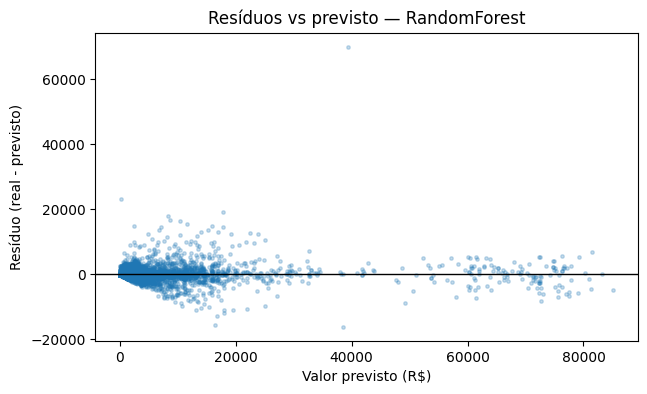

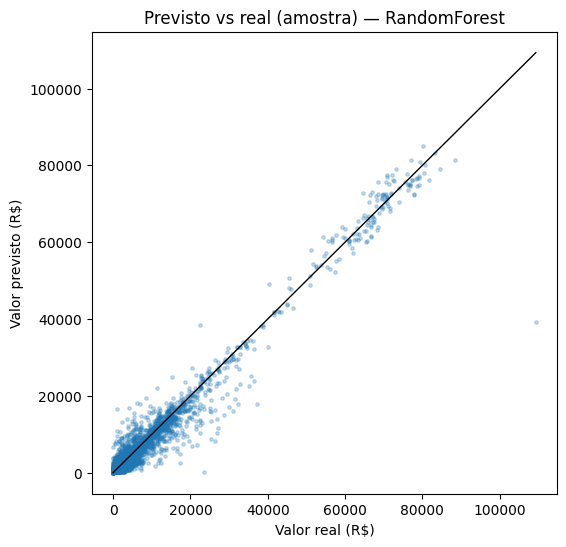

In [7]:
# --- Seção 7: avaliação final no teste (hold-out) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aqui é a hora do teste: a gente treina no treino TODO e mede UMA VEZ no X_test guardado.
# Importante: não mexer mais em hiperparâmetro depois de olhar o teste.

# Candidatos finais: como RF e HGB ficaram próximos na seção 6, vale avaliar os dois no teste.
# (best_pipeline vem da seção 6; mas a gente refaz o fit no treino completo pra ficar correto.)

candidatos = {
    "RandomForest": search_rf.best_estimator_,
    "HistGradientBoosting": search_hgb.best_estimator_,
    "Ridge": search_ridge.best_estimator_,
}

linhas_test = []
modelos_fitados = {}

for nome, est in candidatos.items():
    # Clona pra evitar levar estado de treino da busca (que foi em subamostra)
    modelo = clone(est)

    # Treina com o TREINO completo
    modelo.fit(X_train_fe, y_train)

    # Prediz no TESTE guardado
    y_pred = modelo.predict(X_test_fe)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae = float(mean_absolute_error(y_test, y_pred))
    r2 = float(r2_score(y_test, y_pred))

    linhas_test.append({"modelo": nome, "RMSE_test": rmse, "MAE_test": mae, "R2_test": r2})
    modelos_fitados[nome] = (modelo, y_pred)

resultados_test = pd.DataFrame(linhas_test).sort_values("RMSE_test")
display(resultados_test)

MODEL_NAME_BEST_TEST = resultados_test.iloc[0]["modelo"]
print("\nMelhor no teste (menor RMSE):", MODEL_NAME_BEST_TEST)

# Gráficos: pra não travar com centenas de milhares de pontos, a gente amostra só para plotar
N_PLOT = 50_000
idx_plot = y_test.sample(n=min(N_PLOT, len(y_test)), random_state=42).index

modelo_best, y_pred_best = modelos_fitados[MODEL_NAME_BEST_TEST]
y_pred_plot = pd.Series(y_pred_best, index=X_test_fe.index).loc[idx_plot]
y_true_plot = y_test.loc[idx_plot]
resid_plot = y_true_plot - y_pred_plot

plt.figure(figsize=(7, 4))
plt.scatter(y_pred_plot, resid_plot, s=6, alpha=0.25)
plt.axhline(0, color="black", linewidth=1)
plt.title(f"Resíduos vs previsto — {MODEL_NAME_BEST_TEST}")
plt.xlabel("Valor previsto (R$)")
plt.ylabel("Resíduo (real - previsto)")
plt.show()

plt.figure(figsize=(6, 6))
plt.scatter(y_true_plot, y_pred_plot, s=6, alpha=0.25)
lim = max(y_true_plot.max(), y_pred_plot.max())
plt.plot([0, lim], [0, lim], color="black", linewidth=1)
plt.title(f"Previsto vs real (amostra) — {MODEL_NAME_BEST_TEST}")
plt.xlabel("Valor real (R$)")
plt.ylabel("Valor previsto (R$)")
plt.show()


### Interpretação (seção 7 — teste)

#### Resultado no teste (o que vale “de verdade” no relatório)

Aqui a avaliação já é no **conjunto de teste** separado lá na seção 3. Ou seja: é a medida mais próxima do que o modelo entrega fora do treino (dentro do mesmo padrão da base).

Pelos números obtidos:

- **RandomForest**: **RMSE ≈ 812,04**, **MAE ≈ 302,96**, **R² ≈ 0,9623**
- **Ridge**: RMSE ≈ 1191,81, MAE ≈ 465,22, R² ≈ 0,9188
- **HistGradientBoosting**: RMSE ≈ 1247,47, MAE ≈ 390,12, R² ≈ 0,9110

A conclusão direta é que a **RandomForest generalizou melhor** no teste (menor RMSE, menor MAE e maior R²). Na prática, o erro típico (MAE) ficou na casa de **~R$ 303** por registro.

#### Por que o RMSE é bem maior que o MAE (e o que isso diz sobre o problema)

O RMSE dá mais peso para erros grandes. Como o **Valor total** tem cauda longa (poucos casos muito caros), é esperado ver RMSE bem acima do MAE: alguns registros extremos “puxam” o RMSE pra cima mesmo quando a maioria está com erro moderado.

#### Leitura dos gráficos

- **Resíduos vs previsto (RandomForest):** a nuvem fica bem centrada em torno de 0 para a faixa de valores baixos/médios, mas aparece um padrão de **variância maior** conforme o valor previsto cresce. Isso é um sinal clássico de **heterocedasticidade**: quanto maior a despesa, maior a incerteza do modelo (normal em despesas públicas, porque existem situações raras/atípicas).
  - Também aparecem alguns **outliers** com resíduos muito altos/baixos. Esses casos geralmente são registros fora do padrão (viagem muito cara, ajustes, combinações de categorias raras etc.).

- **Previsto vs real (amostra):** a maior parte dos pontos acompanha bem a diagonal (boa calibração geral), mas nos valores mais altos dá para notar que o modelo pode **subestimar alguns extremos** (pontos com valor real muito alto e previsto menor). Isso é comum em modelos treinados para minimizar MSE/RMSE: eles tendem a “puxar” extremos em direção ao miolo.

#### Fechamento (decisão do modelo final)

- **Modelo final escolhido:** **RandomForest**, por apresentar o melhor desempenho no teste.
- **O que fica como limitação:** mesmo com R² alto, os gráficos mostram que **os maiores erros concentram-se nos casos de maior custo**, o que precisa ser mencionado na seção 8 (discussão crítica), junto da cauda longa e de registros raros.
- **Boa prática:** depois de avaliar no teste, a gente evita voltar e ajustar hiperparâmetros guiado por esse resultado. O teste entra como referência final para escolher o modelo do relatório.


## 8. Discussão crítica

### O que aprendemos com o modelo (e até onde dá pra confiar)

O objetivo era prever **Valor total (R$)** a partir das características do registro de viagem. Com o pré-processamento definido na seção 4 (engenharia + imputação + one-hot + escala quando necessário) e comparações nas seções 5–7, vimos que modelos baseados em árvores (principalmente **RandomForest**) capturam melhor as relações do problema do que um modelo linear simples.

No **teste** (seção 7), a **RandomForest** foi o modelo que melhor generalizou, com **RMSE ≈ 812**, **MAE ≈ 303** e **R² ≈ 0,962**. Isso indica que, para a maior parte dos casos, o modelo consegue estimar bem a ordem de grandeza da despesa e explicar boa parte da variação do alvo.

### Pontos fortes do trabalho

- **Separação honesta treino/teste:** o teste foi guardado desde a seção 3 e usado só no final.
- **Cuidado com *data leakage*:** removemos variáveis que “entregariam” o total por construção (**Valor diárias** e **Valor passagem**) e não incluímos o próprio alvo em `X`.
- **Modelo final coerente com os dados:** a base tem muitas variáveis categóricas e relações não lineares; *ensembles* de árvores lidam bem com esse cenário.
- **Pipeline reprodutível:** o pré-processamento foi encapsulado e aplicado de forma consistente (fit no treino, transform no teste).

### Pontos fracos / limitações (o que o modelo ainda erra)

- **Cauda longa e casos extremos:** os gráficos mostram que o erro cresce para despesas altas (heterocedasticidade). O modelo pode **subestimar extremos**, o que é esperado quando se otimiza RMSE/MSE.
- **Interpretação limitada:** RandomForest é forte, mas não é tão “explicável” quanto um modelo linear. Para auditoria, pode ser necessário complementar com análise de importância de variáveis e explicações locais.
- **Amostragem para CV/busca:** para viabilizar tempo/RAM, a otimização usou subamostras do treino. Isso é aceitável no relatório, mas pode alterar levemente o ranking e os melhores parâmetros.

### Limitações dos dados (SCDP)

- **Granularidade:** pode haver múltiplas linhas por viagem/trecho; isso cria dependência entre registros (não são observações totalmente independentes).
- **Ausentes e categorias raras:** variáveis como município/UF e categoria podem ter muitos valores faltantes ou pouca ocorrência; o one-hot com limite de categorias resolve parte do problema, mas não “cria” informação onde não existe.
- **Desalinhamento temporal:** datas de viagem e data de registro/pagamento podem não representar o mesmo momento do gasto; isso atrapalha análises temporais mais rigorosas.
- **Escopo do arquivo:** o modelo só vale para o recorte do CSV utilizado e pode mudar se o portal atualizar o padrão de preenchimento.

### Melhorias futuras (se tivesse mais tempo)

- **Transformação do alvo:** treinar com `log1p(valor_total)` e depois voltar para R$ pode reduzir o peso dos extremos e melhorar RMSE/estabilidade.
- **Validação temporal:** separar treino/teste por período (ex.: anos anteriores vs ano mais recente) para simular previsão futura.
- **Modelos com GPU:** XGBoost/LightGBM/CatBoost poderiam acelerar e, em alguns cenários, melhorar desempenho.
- **Explicabilidade:** usar *permutation importance* e/ou SHAP (em amostra) para interpretar quais variáveis mais puxam o custo.

### Fechamento

Dentro do escopo do trabalho, a abordagem mostrou que é possível prever **Valor total** com boa qualidade média, mas com maior incerteza nos casos caros/raros. O modelo final (**RandomForest**) é adequado para apoiar análise de gastos e triagem de registros, desde que as limitações (extremos e dependência entre linhas) sejam reconhecidas.

---
